# 🩹 Two-Stage Wound Analysis System

**Stage 1:** U-Net Segmentation (Wound Localization)  
**Stage 2:** EfficientNet-B0 Classification (Infected vs Non-Infected)

---

## Cell 1: Mount Google Drive (For Colab Only)
Skip this cell if running locally

In [13]:
pip install matplotlib

     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ------- -------------------------------- 10.2/52.8 kB ? eta -:--:--
     -------------- ----------------------- 20.5/52.8 kB 320.0 kB/s eta 0:00:01
     ------------------------------------ - 51.2/52.8 kB 372.4 kB/s eta 0:00:01
     -------------------------------------- 52.8/52.8 kB 387.2 kB/s eta 0:00:00
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/116.4 kB ? eta -:--:--
     ---------- ---------------------------- 30.7/116.4 kB 1.4 MB/s eta 0:00:01
     ---------------------- -------------- 71.7/116.4 kB 991.0 kB/s eta 0:00:01
     -------------------------------------- 116.4/116.4 kB 1.1 MB/s eta 0:00:00
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
    --------------------------------------- 0.2/8.1 MB 5.3 MB/s eta 0:00:02
   - ----------------------


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Cell 2: Install Dependencies & Imports

In [5]:
# Install any missing packages (uncomment if needed)
# !pip install torch torchvision matplotlib pillow numpy


import os
import sys
import glob
import shutil
import logging
from pathlib import Path
from typing import Tuple, Optional, List, Callable
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.amp import GradScaler, autocast
from torchvision import transforms, datasets, models
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt


# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cpu


## Cell 3: Configuration ⚙️
**IMPORTANT:** Update the paths below to match your data location!

In [6]:
class Config:
    """Centralized configuration for paths and hyperparameters."""
    
    # ========================================================================
    # UPDATE THESE PATHS TO YOUR DATA LOCATION!
    # ========================================================================
    
    # For LOCAL Windows:
    SEGMENTATION_ROOT = r"C:\Users\PC\Desktop\GraduationProject\MyProjectSTILL\FirstTry\SegementationT+S+V"
    CLASSIFICATION_ROOT = r"C:\Users\PC\Desktop\GraduationProject\MyProjectSTILL\FirstTry\TRAINTEST"
    OUTPUT_DIR = r"C:\Users\PC\Desktop\GraduationProject\MyProjectSTILL\FirstTry\outputs"
    
    # For GOOGLE COLAB (uncomment and modify):
    # SEGMENTATION_ROOT = "/content/drive/MyDrive/WoundData/SegementationT+S+V"
    # CLASSIFICATION_ROOT = "/content/drive/MyDrive/WoundData/TRAINTEST"
    # OUTPUT_DIR = "/content/drive/MyDrive/WoundData/outputs"
    
    # ========================================================================
    
    CROPPED_DATA_DIR = os.path.join(OUTPUT_DIR, "cropped_classification_data")
    MODEL_SAVE_DIR = os.path.join(OUTPUT_DIR, "models")
    
    # Segmentation hyperparameters
    SEG_IMAGE_SIZE = 256
    SEG_BATCH_SIZE = 16
    SEG_EPOCHS = 5        # Increase to 30-50 for better results
    SEG_LEARNING_RATE = 1e-3
    
    # Classification hyperparameters
    CLS_IMAGE_SIZE = 224
    CLS_BATCH_SIZE = 32
    CLS_EPOCHS = 25        # Increase to 20-30 for better results
    CLS_LEARNING_RATE = 1e-3
    
    # DataLoader settings
    NUM_WORKERS = 2 if torch.cuda.is_available() else 0
    
    # Device
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    @classmethod
    def create_directories(cls):
        """Create necessary output directories."""
        os.makedirs(cls.OUTPUT_DIR, exist_ok=True)
        os.makedirs(cls.CROPPED_DATA_DIR, exist_ok=True)
        os.makedirs(cls.MODEL_SAVE_DIR, exist_ok=True)
        
        for split in ['Train', 'test', 'Valid']:
            for label in ['infected', 'non-infected']:
                os.makedirs(os.path.join(cls.CROPPED_DATA_DIR, split, label), exist_ok=True)
        
        print("✅ Directories created!")

# Create directories
Config.create_directories()

print(f"\n📁 Segmentation data: {Config.SEGMENTATION_ROOT}")
print(f"📁 Classification data: {Config.CLASSIFICATION_ROOT}")
print(f"📁 Output directory: {Config.OUTPUT_DIR}")
print(f"\n🖥️ Device: {Config.DEVICE}")
print(f"📊 Seg Epochs: {Config.SEG_EPOCHS}, Cls Epochs: {Config.CLS_EPOCHS}")

✅ Directories created!

📁 Segmentation data: C:\Users\PC\Desktop\GraduationProject\MyProjectSTILL\FirstTry\SegementationT+S+V
📁 Classification data: C:\Users\PC\Desktop\GraduationProject\MyProjectSTILL\FirstTry\TRAINTEST
📁 Output directory: C:\Users\PC\Desktop\GraduationProject\MyProjectSTILL\FirstTry\outputs

🖥️ Device: cpu
📊 Seg Epochs: 5, Cls Epochs: 25


## Cell 4: Segmentation Dataset Class

In [7]:
class WoundSegmentationDataset(Dataset):
    """
    Custom PyTorch Dataset for wound segmentation.
    
    Expected structure:
    ├── train/
    │   ├── images/
    │   └── labels/
    """
    
    def __init__(self, root_dir: str, split: str = 'train', image_size: int = 256, augment: bool = False):
        self.root_dir = root_dir
        self.split = split
        self.image_size = image_size
        self.augment = augment
        
        self.images_dir = os.path.join(root_dir, split, 'images')
        self.masks_dir = os.path.join(root_dir, split, 'labels')
        
        if not os.path.exists(self.images_dir):
            raise ValueError(f"Images directory not found: {self.images_dir}")
        if not os.path.exists(self.masks_dir):
            raise ValueError(f"Masks directory not found: {self.masks_dir}")
        
        self.image_files = self._get_image_files()
        
        if len(self.image_files) == 0:
            raise ValueError(f"No images found in {self.images_dir}")
        
        self.image_transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        
        self.mask_transform = transforms.Compose([
            transforms.Resize((image_size, image_size), interpolation=transforms.InterpolationMode.NEAREST),
            transforms.ToTensor()
        ])
    
    def _get_image_files(self) -> List[str]:
        image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.bmp', '*.tif', '*.tiff']
        image_files = []
        
        for ext in image_extensions:
            pattern = os.path.join(self.images_dir, ext)
            image_files.extend(glob.glob(pattern))
            image_files.extend(glob.glob(pattern.upper()))
        
        valid_files = []
        for img_path in image_files:
            mask_path = self._get_mask_path(img_path)
            if os.path.exists(mask_path):
                valid_files.append(img_path)
        
        return sorted(list(set(valid_files)))
    
    def _get_mask_path(self, image_path: str) -> str:
        base_name = os.path.splitext(os.path.basename(image_path))[0]
        for ext in ['.png', '.jpg', '.jpeg', '.bmp', '.tif']:
            mask_path = os.path.join(self.masks_dir, base_name + ext)
            if os.path.exists(mask_path):
                return mask_path
        return os.path.join(self.masks_dir, base_name + '.png')
    
    def __len__(self) -> int:
        return len(self.image_files)
    
    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        image_path = self.image_files[idx]
        image = Image.open(image_path).convert('RGB')
        
        mask_path = self._get_mask_path(image_path)
        mask = Image.open(mask_path).convert('L')
        
        if self.augment:
            image, mask = self._apply_augmentation(image, mask)
        
        image = self.image_transform(image)
        mask = self.mask_transform(mask)
        mask = (mask > 0.5).float()
        
        return image, mask
    
    def _apply_augmentation(self, image: Image.Image, mask: Image.Image) -> Tuple[Image.Image, Image.Image]:
        if np.random.random() > 0.5:
            image = transforms.functional.hflip(image)
            mask = transforms.functional.hflip(mask)
        
        if np.random.random() > 0.5:
            image = transforms.functional.vflip(image)
            mask = transforms.functional.vflip(mask)
        
        angle = int(np.random.choice([0, 90, 180, 270]))
        if angle != 0:
            image = transforms.functional.rotate(image, angle)
            mask = transforms.functional.rotate(mask, angle)
        
        color_jitter = transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)
        image = color_jitter(image)
        
        return image, mask

print("✅ WoundSegmentationDataset class defined!")

✅ WoundSegmentationDataset class defined!


## Cell 5: U-Net Architecture

In [8]:
class DoubleConv(nn.Module):
    """Double convolution block: (Conv -> BN -> ReLU) x 2"""
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.double_conv(x)


class Down(nn.Module):
    """Downscaling block: MaxPool -> DoubleConv"""
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.maxpool_conv(x)


class Up(nn.Module):
    """Upscaling block: Upsample -> Concat -> DoubleConv"""
    def __init__(self, in_channels: int, out_channels: int, bilinear: bool = True):
        super().__init__()
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels)
        else:
            self.up = nn.ConvTranspose2d(in_channels // 2, in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels)
    
    def forward(self, x1: torch.Tensor, x2: torch.Tensor) -> torch.Tensor:
        x1 = self.up(x1)
        diff_y = x2.size()[2] - x1.size()[2]
        diff_x = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diff_x // 2, diff_x - diff_x // 2, diff_y // 2, diff_y - diff_y // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv(nn.Module):
    """Final 1x1 convolution"""
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv(x)


class UNet(nn.Module):
    """U-Net architecture for wound segmentation."""
    def __init__(self, n_channels: int = 3, n_classes: int = 1, bilinear: bool = True):
        super().__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear
        
        # Encoder
        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        factor = 2 if bilinear else 1
        self.down4 = Down(512, 1024 // factor)
        
        # Decoder
        self.up1 = Up(1024, 512 // factor, bilinear)
        self.up2 = Up(512, 256 // factor, bilinear)
        self.up3 = Up(256, 128 // factor, bilinear)
        self.up4 = Up(128, 64, bilinear)
        self.outc = OutConv(64, n_classes)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        
        return self.outc(x)

print("✅ U-Net architecture defined!")

✅ U-Net architecture defined!


## Cell 6: Loss Functions

In [9]:
class DiceLoss(nn.Module):
    """Dice Loss for medical image segmentation."""
    def __init__(self, smooth: float = 1e-6):
        super().__init__()
        self.smooth = smooth
    
    def forward(self, predictions: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        predictions = torch.sigmoid(predictions)
        predictions = predictions.view(-1)
        targets = targets.view(-1)
        
        intersection = (predictions * targets).sum()
        dice = (2. * intersection + self.smooth) / (predictions.sum() + targets.sum() + self.smooth)
        
        return 1 - dice


class DiceBCELoss(nn.Module):
    """Combined Dice and Binary Cross-Entropy loss."""
    def __init__(self, dice_weight: float = 0.5, bce_weight: float = 0.5):
        super().__init__()
        self.dice_loss = DiceLoss()
        self.bce_loss = nn.BCEWithLogitsLoss()
        self.dice_weight = dice_weight
        self.bce_weight = bce_weight
    
    def forward(self, predictions: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        return (self.dice_weight * self.dice_loss(predictions, targets) + 
                self.bce_weight * self.bce_loss(predictions, targets))

print("✅ Loss functions defined!")

✅ Loss functions defined!


## Cell 7: Wound Cropping Utility

In [10]:
def crop_wound_from_mask(
    image: np.ndarray,
    mask: np.ndarray,
    padding: int = 20,
    min_size: int = 50
) -> Optional[np.ndarray]:
    """
    Crop the wound region from an image using the predicted mask.
    """
    binary_mask = (mask > 0.5).astype(np.uint8)
    coords = np.where(binary_mask > 0)
    
    if len(coords[0]) == 0:
        return image
    
    y_min, y_max = coords[0].min(), coords[0].max()
    x_min, x_max = coords[1].min(), coords[1].max()
    
    h, w = image.shape[:2]
    y_min = max(0, y_min - padding)
    y_max = min(h, y_max + padding)
    x_min = max(0, x_min - padding)
    x_max = min(w, x_max + padding)
    
    if (y_max - y_min) < min_size or (x_max - x_min) < min_size:
        return image
    
    return image[y_min:y_max, x_min:x_max]

print("✅ Cropping utility defined!")

✅ Cropping utility defined!


## Cell 8: Segmentation Trainer

In [20]:
class SegmentationTrainer:
    """Trainer class for U-Net segmentation model."""
    
    def __init__(self, model, train_loader, val_loader, criterion, optimizer, device):
        self.model = model.to(device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.criterion = criterion
        self.optimizer = optimizer
        self.device = device
        
        self.scaler = GradScaler('cuda') if device.type == 'cuda' else None
        self.use_amp = device.type == 'cuda'
        
        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
        self.best_dice = 0.0
    
    def _calculate_dice(self, predictions, targets, smooth=1e-6):
        predictions = predictions.view(-1)
        targets = targets.view(-1)
        intersection = (predictions * targets).sum()
        dice = (2. * intersection + smooth) / (predictions.sum() + targets.sum() + smooth)
        return dice.item()
    
    def train_epoch(self):
        self.model.train()
        total_loss, total_dice = 0.0, 0.0
        
        for batch_idx, (images, masks) in enumerate(self.train_loader):
            images = images.to(self.device, non_blocking=True)
            masks = masks.to(self.device, non_blocking=True)
            
            self.optimizer.zero_grad()
            
            if self.use_amp:
                with autocast('cuda'):
                    outputs = self.model(images)
                    loss = self.criterion(outputs, masks)
                self.scaler.scale(loss).backward()
                self.scaler.step(self.optimizer)
                self.scaler.update()
            else:
                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                loss.backward()
                self.optimizer.step()
            
            with torch.no_grad():
                pred_masks = torch.sigmoid(outputs) > 0.5
                dice = self._calculate_dice(pred_masks.float(), masks)
            
            total_loss += loss.item()
            total_dice += dice
            
            if (batch_idx + 1) % 20 == 0:
                print(f"    Batch [{batch_idx+1}/{len(self.train_loader)}] Loss: {loss.item():.4f}, Dice: {dice:.4f}")
        
        return total_loss / len(self.train_loader), total_dice / len(self.train_loader)
    
    def validate(self):
        self.model.eval()
        total_loss, total_dice = 0.0, 0.0
        
        with torch.no_grad():
            for images, masks in self.val_loader:
                images = images.to(self.device, non_blocking=True)
                masks = masks.to(self.device, non_blocking=True)
                
                if self.use_amp:
                    with autocast('cuda'):
                        outputs = self.model(images)
                        loss = self.criterion(outputs, masks)
                else:
                    outputs = self.model(images)
                    loss = self.criterion(outputs, masks)
                
                pred_masks = torch.sigmoid(outputs) > 0.5
                dice = self._calculate_dice(pred_masks.float(), masks)
                
                total_loss += loss.item()
                total_dice += dice
        
        return total_loss / len(self.val_loader), total_dice / len(self.val_loader)
    
    def train(self, epochs, save_path):
        print(f"\n🚀 Starting Segmentation Training for {epochs} epochs...\n")
        
        for epoch in range(epochs):
            print(f"Epoch [{epoch+1}/{epochs}]")
            print("-" * 40)
            
            train_loss, train_dice = self.train_epoch()
            print(f"  Train Loss: {train_loss:.4f}, Train Dice: {train_dice:.4f}")
            
            val_loss, val_dice = self.validate()
            print(f"  Val Loss: {val_loss:.4f}, Val Dice: {val_dice:.4f}")
            
            self.scheduler.step(val_loss)
            
            if val_dice > self.best_dice:
                self.best_dice = val_dice
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': self.model.state_dict(),
                    'val_dice': val_dice,
                }, save_path)
                print(f"  ✅ Saved best model with Dice: {val_dice:.4f}")
            print()
        
        print(f"🏁 Training complete! Best Dice: {self.best_dice:.4f}")
        return self.best_dice

print("✅ SegmentationTrainer class defined!")

✅ SegmentationTrainer class defined!


## Cell 9: Classification Components

In [21]:
def get_classification_transforms(train: bool = True):
    """Get transforms for classification."""
    if train:
        return transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.RandomCrop(Config.CLS_IMAGE_SIZE),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.3),
            transforms.RandomRotation(degrees=30),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
    else:
        return transforms.Compose([
            transforms.Resize((Config.CLS_IMAGE_SIZE, Config.CLS_IMAGE_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])


def create_efficientnet_classifier(num_classes: int = 2, pretrained: bool = True):
    """Create EfficientNet-B0 model with custom classifier."""
    if pretrained:
        weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
        model = models.efficientnet_b0(weights=weights)
    else:
        model = models.efficientnet_b0(weights=None)
    
    num_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(num_features, 512),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.3),
        nn.Linear(512, num_classes)
    )
    
    return model

print("✅ Classification components defined!")

✅ Classification components defined!


## Cell 10: Classification Trainer

In [11]:
class ClassificationTrainer:
    """Trainer class for classification model."""
    
    def __init__(self, model, train_loader, val_loader, criterion, optimizer, device):
        self.model = model.to(device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.criterion = criterion
        self.optimizer = optimizer
        self.device = device
        
        self.scaler = GradScaler('cuda') if device.type == 'cuda' else None
        self.use_amp = device.type == 'cuda'
        
        self.scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=Config.CLS_EPOCHS, eta_min=1e-6)
        self.best_acc = 0.0
    
    def train_epoch(self):
        self.model.train()
        total_loss, correct, total = 0.0, 0, 0
        
        for batch_idx, (images, labels) in enumerate(self.train_loader):
            images = images.to(self.device, non_blocking=True)
            labels = labels.to(self.device, non_blocking=True)
            
            self.optimizer.zero_grad()
            
            if self.use_amp:
                with autocast('cuda'):
                    outputs = self.model(images)
                    loss = self.criterion(outputs, labels)
                self.scaler.scale(loss).backward()
                self.scaler.step(self.optimizer)
                self.scaler.update()
            else:
                outputs = self.model(images)
                loss = self.criterion(outputs, labels)
                loss.backward()
                self.optimizer.step()
            
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            total_loss += loss.item()
            
            if (batch_idx + 1) % 20 == 0:
                print(f"    Batch [{batch_idx+1}/{len(self.train_loader)}] Loss: {loss.item():.4f}, Acc: {100.*correct/total:.2f}%")
        
        return total_loss / len(self.train_loader), 100. * correct / total
    
    def validate(self):
        self.model.eval()
        total_loss, correct, total = 0.0, 0, 0
        
        with torch.no_grad():
            for images, labels in self.val_loader:
                images = images.to(self.device, non_blocking=True)
                labels = labels.to(self.device, non_blocking=True)
                
                if self.use_amp:
                    with autocast('cuda'):
                        outputs = self.model(images)
                        loss = self.criterion(outputs, labels)
                else:
                    outputs = self.model(images)
                    loss = self.criterion(outputs, labels)
                
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
                total_loss += loss.item()
        
        return total_loss / len(self.val_loader), 100. * correct / total
    
    def train(self, epochs, save_path):
        print(f"\n🚀 Starting Classification Training for {epochs} epochs...\n")
        
        for epoch in range(epochs):
            print(f"Epoch [{epoch+1}/{epochs}]")
            print("-" * 40)
            
            train_loss, train_acc = self.train_epoch()
            print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
            
            val_loss, val_acc = self.validate()
            print(f"  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
            
            self.scheduler.step()
            
            if val_acc > self.best_acc:
                self.best_acc = val_acc
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': self.model.state_dict(),
                    'val_acc': val_acc,
                }, save_path)
                print(f"  ✅ Saved best model with Acc: {val_acc:.2f}%")
            print()
        
        print(f"🏁 Training complete! Best Accuracy: {self.best_acc:.2f}%")
        return self.best_acc

print("✅ ClassificationTrainer class defined!")

✅ ClassificationTrainer class defined!


## Cell 11: Dataset Cropping Function

In [12]:
def crop_classification_dataset(segmentation_model, source_dir, target_dir, device):
    """Use trained segmentation model to crop wound regions."""
    segmentation_model.eval()
    
    seg_transform = transforms.Compose([
        transforms.Resize((Config.SEG_IMAGE_SIZE, Config.SEG_IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    for split in ['Train', 'test', 'Valid']:
        split_dir = os.path.join(source_dir, split)
        
        if not os.path.exists(split_dir):
            print(f"⚠️ Split directory not found: {split_dir}")
            continue
        
        print(f"\n📂 Processing {split} split...")
        
        for class_name in ['infected', 'non-infected']:
            class_dir = os.path.join(split_dir, class_name)
            target_class_dir = os.path.join(target_dir, split, class_name)
            
            if not os.path.exists(class_dir):
                print(f"  ⚠️ Class directory not found: {class_dir}")
                continue
            
            os.makedirs(target_class_dir, exist_ok=True)
            
            image_files = []
            for ext in ['*.jpg', '*.jpeg', '*.png', '*.bmp']:
                image_files.extend(glob.glob(os.path.join(class_dir, ext)))
                image_files.extend(glob.glob(os.path.join(class_dir, ext.upper())))
            
            print(f"  {class_name}: {len(image_files)} images")
            
            for i, img_path in enumerate(image_files):
                try:
                    original_image = Image.open(img_path).convert('RGB')
                    original_np = np.array(original_image)
                    
                    input_tensor = seg_transform(original_image).unsqueeze(0).to(device)
                    
                    with torch.no_grad():
                        mask_output = segmentation_model(input_tensor)
                        mask = torch.sigmoid(mask_output).squeeze().cpu().numpy()
                    
                    mask_resized = np.array(
                        Image.fromarray((mask * 255).astype(np.uint8)).resize(
                            (original_np.shape[1], original_np.shape[0]), Image.NEAREST
                        )
                    ) / 255.0
                    
                    cropped = crop_wound_from_mask(original_np, mask_resized)
                    
                    if cropped is not None:
                        cropped_image = Image.fromarray(cropped)
                        save_path = os.path.join(target_class_dir, os.path.basename(img_path))
                        cropped_image.save(save_path)
                
                except Exception as e:
                    shutil.copy(img_path, os.path.join(target_class_dir, os.path.basename(img_path)))
                
                if (i + 1) % 100 == 0:
                    print(f"    Processed {i+1}/{len(image_files)} images")
    
    print("\n✅ Cropping complete!")

print("✅ Cropping function defined!")

✅ Cropping function defined!


---
# 🏃 STAGE 1: Train Segmentation Model
---

In [24]:
print("="*60)
print("🎯 STAGE 1: SEGMENTATION MODEL TRAINING")
print("="*60)

# Load datasets
print("\n📂 Loading segmentation datasets...")

train_seg_dataset = WoundSegmentationDataset(
    root_dir=Config.SEGMENTATION_ROOT,
    split='train',
    image_size=Config.SEG_IMAGE_SIZE,
    augment=True
)

val_seg_dataset = WoundSegmentationDataset(
    root_dir=Config.SEGMENTATION_ROOT,
    split='validation',
    image_size=Config.SEG_IMAGE_SIZE,
    augment=False
)

print(f"  Train samples: {len(train_seg_dataset)}")
print(f"  Validation samples: {len(val_seg_dataset)}")

# Create data loaders
train_seg_loader = DataLoader(
    train_seg_dataset,
    batch_size=Config.SEG_BATCH_SIZE,
    shuffle=True,
    num_workers=Config.NUM_WORKERS,
    pin_memory=True if Config.DEVICE.type == 'cuda' else False
)

val_seg_loader = DataLoader(
    val_seg_dataset,
    batch_size=Config.SEG_BATCH_SIZE,
    shuffle=False,
    num_workers=Config.NUM_WORKERS,
    pin_memory=True if Config.DEVICE.type == 'cuda' else False
)

# Create model
print("\n🏗️ Initializing U-Net model...")
seg_model = UNet(n_channels=3, n_classes=1, bilinear=True)
print(f"  Parameters: {sum(p.numel() for p in seg_model.parameters()):,}")

# Setup training
seg_criterion = DiceBCELoss(dice_weight=0.5, bce_weight=0.5)
seg_optimizer = optim.AdamW(seg_model.parameters(), lr=Config.SEG_LEARNING_RATE, weight_decay=1e-4)

# Train
seg_trainer = SegmentationTrainer(
    model=seg_model,
    train_loader=train_seg_loader,
    val_loader=val_seg_loader,
    criterion=seg_criterion,
    optimizer=seg_optimizer,
    device=Config.DEVICE
)

seg_save_path = os.path.join(Config.MODEL_SAVE_DIR, 'segmentation_unet.pth')
best_dice = seg_trainer.train(Config.SEG_EPOCHS, seg_save_path)

# Load best model
checkpoint = torch.load(seg_save_path, map_location=Config.DEVICE)
seg_model.load_state_dict(checkpoint['model_state_dict'])
seg_model = seg_model.to(Config.DEVICE)

print(f"\n🏆 Best Segmentation Model Dice: {checkpoint['val_dice']:.4f}")

🎯 STAGE 1: SEGMENTATION MODEL TRAINING

📂 Loading segmentation datasets...
  Train samples: 1620
  Validation samples: 400

🏗️ Initializing U-Net model...
  Parameters: 13,391,361

🚀 Starting Segmentation Training for 5 epochs...

Epoch [1/5]
----------------------------------------
    Batch [20/102] Loss: 0.5997, Dice: 0.2661
    Batch [40/102] Loss: 0.5466, Dice: 0.5281
    Batch [60/102] Loss: 0.5338, Dice: 0.2907
    Batch [80/102] Loss: 0.5130, Dice: 0.2457
    Batch [100/102] Loss: 0.4913, Dice: 0.2777
  Train Loss: 0.5547, Train Dice: 0.3329
  Val Loss: 0.4608, Val Dice: 0.4603
  ✅ Saved best model with Dice: 0.4603

Epoch [2/5]
----------------------------------------
    Batch [20/102] Loss: 0.4182, Dice: 0.5051
    Batch [40/102] Loss: 0.4204, Dice: 0.3409
    Batch [60/102] Loss: 0.3608, Dice: 0.4469
    Batch [80/102] Loss: 0.3007, Dice: 0.5402
    Batch [100/102] Loss: 0.3046, Dice: 0.5154
  Train Loss: 0.3615, Train Dice: 0.4808
  Val Loss: 0.2894, Val Dice: 0.5238
  ✅ S

---
# ✂️ STAGE 2a: Crop Classification Dataset
---

In [ ]:
print("="*60)
print("✂️ CROPPING CLASSIFICATION DATASET")
print("="*60)

crop_classification_dataset(
    segmentation_model=seg_model,
    source_dir=Config.CLASSIFICATION_ROOT,
    target_dir=Config.CROPPED_DATA_DIR,
    device=Config.DEVICE
)

📂 LOADING SAVED SEGMENTATION MODEL
✅ Segmentation model loaded from: C:\Users\PC\Desktop\GraduationProject\MyProjectSTILL\FirstTry\outputs\models\segmentation_unet.pth
   Model Dice score: 0.6047

✂️ CROPPING CLASSIFICATION DATASET

📂 Processing Train split...
  infected: 700 images


KeyboardInterrupt: 

---
# 🏃 STAGE 2b: Train Classification Model
---

In [16]:
print("="*60)
print("🎯 STAGE 2: CLASSIFICATION MODEL TRAINING")
print("="*60)

# Load datasets
print("\n📂 Loading classification datasets...")

train_cls_dataset = datasets.ImageFolder(
    root=os.path.join(Config.CROPPED_DATA_DIR, 'Train'),
    transform=get_classification_transforms(train=True)
)

val_cls_dataset = datasets.ImageFolder(
    root=os.path.join(Config.CROPPED_DATA_DIR, 'Valid'),
    transform=get_classification_transforms(train=False)
)

print(f"  Train samples: {len(train_cls_dataset)}")
print(f"  Validation samples: {len(val_cls_dataset)}")
print(f"  Classes: {train_cls_dataset.classes}")

# Create data loaders
train_cls_loader = DataLoader(
    train_cls_dataset,
    batch_size=Config.CLS_BATCH_SIZE,
    shuffle=True,
    num_workers=Config.NUM_WORKERS,
    pin_memory=True if Config.DEVICE.type == 'cuda' else False
)

val_cls_loader = DataLoader(
    val_cls_dataset,
    batch_size=Config.CLS_BATCH_SIZE,
    shuffle=False,
    num_workers=Config.NUM_WORKERS,
    pin_memory=True if Config.DEVICE.type == 'cuda' else False
)

# Create model
print("\n🏗️ Initializing EfficientNet-B0 model...")
cls_model = create_efficientnet_classifier(num_classes=2, pretrained=True)
print(f"  Parameters: {sum(p.numel() for p in cls_model.parameters()):,}")

# Setup training
cls_criterion = nn.CrossEntropyLoss()
cls_optimizer = optim.AdamW(cls_model.parameters(), lr=Config.CLS_LEARNING_RATE, weight_decay=1e-4)

# Train
cls_trainer = ClassificationTrainer(
    model=cls_model,
    train_loader=train_cls_loader,
    val_loader=val_cls_loader,
    criterion=cls_criterion,
    optimizer=cls_optimizer,
    device=Config.DEVICE
)

cls_save_path = os.path.join(Config.MODEL_SAVE_DIR, 'classification_efficientnet.pth')
best_acc = cls_trainer.train(Config.CLS_EPOCHS, cls_save_path)

# Load best model
checkpoint = torch.load(cls_save_path, map_location=Config.DEVICE)
cls_model.load_state_dict(checkpoint['model_state_dict'])
cls_model = cls_model.to(Config.DEVICE)

print(f"\n🏆 Best Classification Model Accuracy: {checkpoint['val_acc']:.2f}%")

🎯 STAGE 2: CLASSIFICATION MODEL TRAINING

📂 Loading classification datasets...


NameError: name 'get_classification_transforms' is not defined

---
# ✅ Training Complete!
---

In [28]:
print("="*60)
print("🎉 TRAINING COMPLETE!")
print("="*60)

print(f"\n📁 Models saved to: {Config.MODEL_SAVE_DIR}")
print("  - segmentation_unet.pth")
print("  - classification_efficientnet.pth")

print(f"\n📁 Cropped data saved to: {Config.CROPPED_DATA_DIR}")

🎉 TRAINING COMPLETE!

📁 Models saved to: C:\Users\PC\Desktop\GraduationProject\MyProjectSTILL\FirstTry\outputs\models
  - segmentation_unet.pth
  - classification_efficientnet.pth

📁 Cropped data saved to: C:\Users\PC\Desktop\GraduationProject\MyProjectSTILL\FirstTry\outputs\cropped_classification_data


---
# 🔮 Inference: Test on New Images
---

In [2]:
def run_inference(image_path, seg_model, cls_model, device):
    """Run full inference pipeline on a single image."""
    
    # Load image
    original_image = Image.open(image_path).convert('RGB')
    original_np = np.array(original_image)
    
    # Segmentation
    seg_transform = transforms.Compose([
        transforms.Resize((Config.SEG_IMAGE_SIZE, Config.SEG_IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    seg_model.eval()
    with torch.no_grad():
        seg_input = seg_transform(original_image).unsqueeze(0).to(device)
        mask_output = seg_model(seg_input)
        mask = torch.sigmoid(mask_output).squeeze().cpu().numpy()
    
    # Resize mask
    mask_resized = np.array(
        Image.fromarray((mask * 255).astype(np.uint8)).resize(
            (original_np.shape[1], original_np.shape[0]), Image.NEAREST
        )
    ) / 255.0
    
    # Crop
    cropped = crop_wound_from_mask(original_np, mask_resized)
    
    
    # Classification
    cls_transform = get_classification_transforms(train=False)
    cropped_pil = Image.fromarray(cropped)
    
    cls_model.eval()
    with torch.no_grad():
        cls_input = cls_transform(cropped_pil).unsqueeze(0).to(device)
        cls_output = cls_model(cls_input)
        probs = torch.softmax(cls_output, dim=1)
        pred_class = probs.argmax(dim=1).item()
        confidence = probs[0, pred_class].item()
    
    class_names = ['infected', 'non-infected']
    
    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(original_np)
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    axes[1].imshow(mask_resized, cmap='jet', alpha=0.7)
    axes[1].set_title('Segmentation Mask')
    axes[1].axis('off')
    
    axes[2].imshow(cropped)
    color = 'red' if class_names[pred_class] == 'infected' else 'green'
    axes[2].set_title(f'Prediction: {class_names[pred_class].upper()}\nConfidence: {confidence*100:.1f}%', 
                      color=color, fontsize=14, fontweight='bold')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return {
        'prediction': class_names[pred_class],
        'confidence': confidence,
        'infected_prob': probs[0, 0].item(),
        'non_infected_prob': probs[0, 1].item()
    }

print("✅ Inference function ready!")
print("\n📝 Usage:")
print('   result = run_inference("path/to/wound_image.jpg", seg_model, cls_model, Config.DEVICE)')

✅ Inference function ready!

📝 Usage:
   result = run_inference("path/to/wound_image.jpg", seg_model, cls_model, Config.DEVICE)


In [ ]:
# Test inference on a sample image (update path to your test image)
# test_image_path = "path/to/your/test/image.jpg"
# result = run_inference(test_image_path, seg_model, cls_model, Config.DEVICE)
# print(result)

In [3]:
# Update with your test image path
test_image_path = r"C:\Users\PC\Desktop\GraduationProject\MyProjectSTILL\FirstTry\TesT.png"
result = run_inference(test_image_path, seg_model, cls_model, Config.DEVICE)
print(result)

NameError: name 'seg_model' is not defined

Using device: cpu

📂 Loading saved models...
✅ Segmentation model loaded! (Dice: 0.6047)
✅ Classification model loaded! (Accuracy: 78.24%)

🔍 Analyzing: C:\Users\PC\Desktop\GraduationProject\MyProjectSTILL\FirstTry\Screenshot 2026-02-16 175818.png
   Image size: 715x482
   Step 1: Segmenting wound region...
   Step 2: Cropping wound region...
   Step 3: Classifying infection status...

🩹 WOUND ANALYSIS RESULTS
   Prediction:  NON-INFECTED
   Confidence:  84.5%
   Infected probability:     15.5%
   Non-infected probability: 84.5%


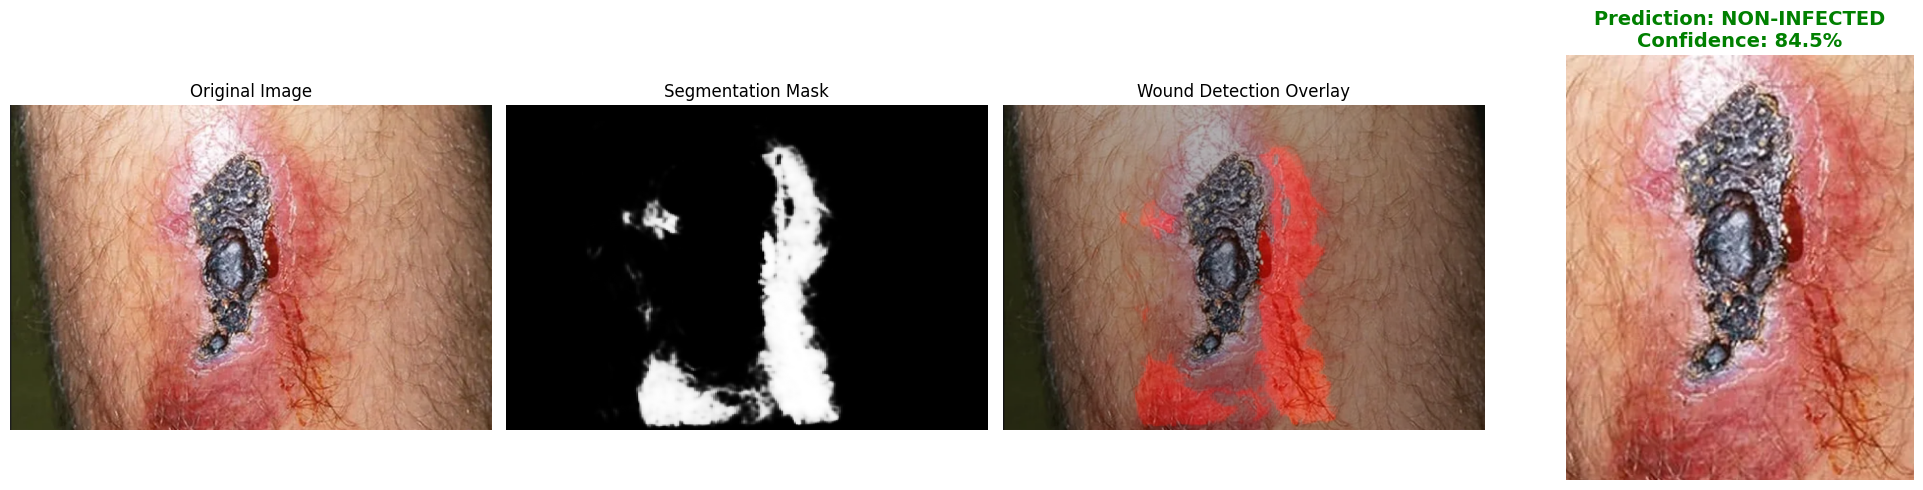


💾 Result saved as 'wound_analysis_result.png'


In [2]:
# =============================================================================
# 🔮 Wound Analysis - Load Saved Models & Test on New Image
# =============================================================================
# Run this code after training to test on new images
# =============================================================================

import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models

# =============================================================================
# CONFIGURATION - UPDATE THESE PATHS!
# =============================================================================

# Path to your trained models
MODEL_DIR = r"C:\Users\PC\Desktop\GraduationProject\MyProjectSTILL\FirstTry\outputs\models"

# Path to the image you want to test
TEST_IMAGE_PATH = r"C:\Users\PC\Desktop\GraduationProject\MyProjectSTILL\FirstTry\YOUR_IMAGE.jpg"  # <-- UPDATE THIS!

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# =============================================================================
# MODEL ARCHITECTURES (same as training)
# =============================================================================

class DoubleConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return self.double_conv(x)


class Down(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )
    
    def forward(self, x):
        return self.maxpool_conv(x)


class Up(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, bilinear: bool = True):
        super().__init__()
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels)
        else:
            self.up = nn.ConvTranspose2d(in_channels // 2, in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels)
    
    def forward(self, x1, x2):
        x1 = self.up(x1)
        diff_y = x2.size()[2] - x1.size()[2]
        diff_x = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diff_x // 2, diff_x - diff_x // 2, diff_y // 2, diff_y - diff_y // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)
    
    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, n_channels: int = 3, n_classes: int = 1, bilinear: bool = True):
        super().__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear
        
        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        factor = 2 if bilinear else 1
        self.down4 = Down(512, 1024 // factor)
        
        self.up1 = Up(1024, 512 // factor, bilinear)
        self.up2 = Up(512, 256 // factor, bilinear)
        self.up3 = Up(256, 128 // factor, bilinear)
        self.up4 = Up(128, 64, bilinear)
        self.outc = OutConv(64, n_classes)
    
    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        
        return self.outc(x)


def create_efficientnet_classifier(num_classes: int = 2):
    model = models.efficientnet_b0(weights=None)
    num_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(num_features, 512),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.3),
        nn.Linear(512, num_classes)
    )
    return model


# =============================================================================
# LOAD SAVED MODELS
# =============================================================================

print("\n📂 Loading saved models...")

# Load Segmentation Model
seg_model = UNet(n_channels=3, n_classes=1, bilinear=True)
seg_checkpoint = torch.load(
    os.path.join(MODEL_DIR, 'segmentation_unet.pth'), 
    map_location=DEVICE
)
seg_model.load_state_dict(seg_checkpoint['model_state_dict'])
seg_model = seg_model.to(DEVICE)
seg_model.eval()
print(f"✅ Segmentation model loaded! (Dice: {seg_checkpoint['val_dice']:.4f})")

# Load Classification Model
cls_model = create_efficientnet_classifier(num_classes=2)
cls_checkpoint = torch.load(
    os.path.join(MODEL_DIR, 'classification_efficientnet.pth'), 
    map_location=DEVICE
)
cls_model.load_state_dict(cls_checkpoint['model_state_dict'])
cls_model = cls_model.to(DEVICE)
cls_model.eval()
print(f"✅ Classification model loaded! (Accuracy: {cls_checkpoint['val_acc']:.2f}%)")


# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def crop_wound_from_mask(image, mask, padding=20, min_size=50):
    """Crop wound region using segmentation mask."""
    binary_mask = (mask > 0.5).astype(np.uint8)
    coords = np.where(binary_mask > 0)
    
    if len(coords[0]) == 0:
        return image
    
    y_min, y_max = coords[0].min(), coords[0].max()
    x_min, x_max = coords[1].min(), coords[1].max()
    
    h, w = image.shape[:2]
    y_min = max(0, y_min - padding)
    y_max = min(h, y_max + padding)
    x_min = max(0, x_min - padding)
    x_max = min(w, x_max + padding)
    
    if (y_max - y_min) < min_size or (x_max - x_min) < min_size:
        return image
    
    return image[y_min:y_max, x_min:x_max]


# =============================================================================
# INFERENCE FUNCTION
# =============================================================================

def analyze_wound(image_path):
    """
    Analyze a wound image: segment, crop, and classify.
    
    Args:
        image_path: Path to the wound image
    
    Returns:
        Dictionary with prediction results
    """
    print(f"\n🔍 Analyzing: {image_path}")
    
    # Check if file exists
    if not os.path.exists(image_path):
        print(f"❌ Error: Image not found at {image_path}")
        return None
    
    # Load image
    original_image = Image.open(image_path).convert('RGB')
    original_np = np.array(original_image)
    print(f"   Image size: {original_np.shape[1]}x{original_np.shape[0]}")
    
    # Segmentation transform
    seg_transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Classification transform
    cls_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Step 1: Segmentation
    print("   Step 1: Segmenting wound region...")
    with torch.no_grad():
        seg_input = seg_transform(original_image).unsqueeze(0).to(DEVICE)
        mask_output = seg_model(seg_input)
        mask = torch.sigmoid(mask_output).squeeze().cpu().numpy()
    
    # Resize mask to original size
    mask_resized = np.array(
        Image.fromarray((mask * 255).astype(np.uint8)).resize(
            (original_np.shape[1], original_np.shape[0]), 
            Image.NEAREST
        )
    ) / 255.0
    
    # Step 2: Crop wound region
    print("   Step 2: Cropping wound region...")
    cropped = crop_wound_from_mask(original_np, mask_resized)
    
    # Step 3: Classification
    print("   Step 3: Classifying infection status...")
    cropped_pil = Image.fromarray(cropped)
    
    with torch.no_grad():
        cls_input = cls_transform(cropped_pil).unsqueeze(0).to(DEVICE)
        cls_output = cls_model(cls_input)
        probs = torch.softmax(cls_output, dim=1)
        pred_class = probs.argmax(dim=1).item()
        confidence = probs[0, pred_class].item()
    
    class_names = ['infected', 'non-infected']
    prediction = class_names[pred_class]
    
    # Print results
    print(f"\n{'='*50}")
    print(f"🩹 WOUND ANALYSIS RESULTS")
    print(f"{'='*50}")
    print(f"   Prediction:  {prediction.upper()}")
    print(f"   Confidence:  {confidence*100:.1f}%")
    print(f"   Infected probability:     {probs[0, 0].item()*100:.1f}%")
    print(f"   Non-infected probability: {probs[0, 1].item()*100:.1f}%")
    print(f"{'='*50}")
    
    # Visualize results
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    # Original image
    axes[0].imshow(original_np)
    axes[0].set_title('Original Image', fontsize=12)
    axes[0].axis('off')
    
    # Segmentation mask
    axes[1].imshow(mask_resized, cmap='gray')
    axes[1].set_title('Segmentation Mask', fontsize=12)
    axes[1].axis('off')
    
    # Overlay
    overlay = original_np.copy()
    mask_rgb = np.zeros_like(overlay)
    mask_rgb[:, :, 0] = (mask_resized * 255).astype(np.uint8)  # Red channel
    overlay = (overlay * 0.7 + mask_rgb * 0.3).astype(np.uint8)
    axes[2].imshow(overlay)
    axes[2].set_title('Wound Detection Overlay', fontsize=12)
    axes[2].axis('off')
    
    # Cropped + Prediction
    axes[3].imshow(cropped)
    color = 'red' if prediction == 'infected' else 'green'
    axes[3].set_title(
        f'Prediction: {prediction.upper()}\nConfidence: {confidence*100:.1f}%', 
        fontsize=14, 
        fontweight='bold',
        color=color
    )
    axes[3].axis('off')
    
    plt.tight_layout()
    plt.savefig('wound_analysis_result.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n💾 Result saved as 'wound_analysis_result.png'")
    
    return {
        'prediction': prediction,
        'confidence': confidence,
        'infected_probability': probs[0, 0].item(),
        'non_infected_probability': probs[0, 1].item()
    }


# =============================================================================
# RUN INFERENCE
# =============================================================================

# UPDATE THE PATH BELOW TO YOUR TEST IMAGE!
# ==========================================

# Option 1: Set the path here
TEST_IMAGE_PATH = r"C:\Users\PC\Desktop\GraduationProject\MyProjectSTILL\FirstTry\Screenshot 2026-02-16 175818.png"

# Option 2: Or uncomment this to enter path interactively
# TEST_IMAGE_PATH = input("Enter the path to your wound image: ")

# Run analysis
if os.path.exists(TEST_IMAGE_PATH):
    result = analyze_wound(TEST_IMAGE_PATH)
else:
    print(f"\n⚠️ Please update TEST_IMAGE_PATH with your actual image path!")
    print(f"   Current path: {TEST_IMAGE_PATH}")
    print(f"\n   Example:")
    print(r'   TEST_IMAGE_PATH = r"C:\Users\PC\Desktop\wound_test.jpg"')

In [4]:
# =============================================================================
# RE-TRAIN CLASSIFICATION ONLY (30 epochs)
# =============================================================================

print("="*60)
print("🎯 TRAINING CLASSIFICATION MODEL (30 epochs)")
print("="*60)

# Load datasets
train_cls_dataset = datasets.ImageFolder(
    root=os.path.join(Config.CROPPED_DATA_DIR, 'Train'),
    transform=get_classification_transforms(train=True)
)

val_cls_dataset = datasets.ImageFolder(
    root=os.path.join(Config.CROPPED_DATA_DIR, 'Valid'),
    transform=get_classification_transforms(train=False)
)

print(f"  Train samples: {len(train_cls_dataset)}")
print(f"  Validation samples: {len(val_cls_dataset)}")

# Create data loaders
train_cls_loader = DataLoader(train_cls_dataset, batch_size=32, shuffle=True, num_workers=0)
val_cls_loader = DataLoader(val_cls_dataset, batch_size=32, shuffle=False, num_workers=0)

# Create model
cls_model = create_efficientnet_classifier(num_classes=2, pretrained=True)

# Setup training
cls_criterion = nn.CrossEntropyLoss()
cls_optimizer = optim.AdamW(cls_model.parameters(), lr=1e-4, weight_decay=1e-4)

# Create trainer
cls_trainer = ClassificationTrainer(
    model=cls_model,
    train_loader=train_cls_loader,
    val_loader=val_cls_loader,
    criterion=cls_criterion,
    optimizer=cls_optimizer,
    device=Config.DEVICE
)

# Fix scheduler for 30 epochs
cls_trainer.scheduler = optim.lr_scheduler.CosineAnnealingLR(cls_optimizer, T_max=30, eta_min=1e-6)

# Train 30 epochs
cls_save_path = os.path.join(Config.MODEL_SAVE_DIR, 'classification_efficientnet.pth')
cls_trainer.train(30, cls_save_path)

# Load best
checkpoint = torch.load(cls_save_path, map_location=Config.DEVICE)
cls_model.load_state_dict(checkpoint['model_state_dict'])
cls_model = cls_model.to(Config.DEVICE)

print(f"\n🏆 Best Accuracy: {checkpoint['val_acc']:.2f}%")

🎯 TRAINING CLASSIFICATION MODEL (30 epochs)


NameError: name 'get_classification_transforms' is not defined